# Ejercicios ensembling
En este ejercicio vas a realizar prediciones sobre un dataset de ciudadanos indios diabéticos. Se trata de un problema de clasificación en el que intentaremos predecir 1 (diabético) 0 (no diabético).

- preg: Número de embarazos que ha tenido la paciente.

- plas (Plasma glucose concentration): Concentración de glucosa en plasma a las 2 horas durante una prueba oral de tolerancia a la glucosa.
→ Es uno de los valores más importantes para predecir diabetes.

- pres (Diastolic blood pressure): Presión arterial diastólica (mm Hg).

- skin (Triceps skin fold thickness): Grosor del pliegue cutáneo del tríceps (mm).
→ Se usa como indicador indirecto de grasa corporal.

- test (2-Hour serum insulin): Insulina sérica a las 2 horas (mu U/ml).
→ Muchas veces faltan valores y aparecen como 0 en el dataset original.

- mass (Body Mass Index – BMI): Índice de masa corporal:
BMI = peso (kg) / altura² (m²)

- pedi (Diabetes pedigree function):Función de pedigrí de diabetes:
mide riesgo hereditario/familiar de diabetes.

- age: Edad de la paciente (años).

- class: Variable objetivo:

1 → Tiene diabetes

0 → No tiene diabetes

### 1. Carga las librerias que consideres comunes al notebook

In [128]:
import pandas as pd
import seaborn as sns
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, VotingRegressor, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost

### 2. Lee los datos de [esta direccion](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv)
Los nombres de columnas son:
```Python
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
```

In [129]:
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df_indios = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv", names=names)
df_indios

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [130]:
df_indios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [131]:
df_indios.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


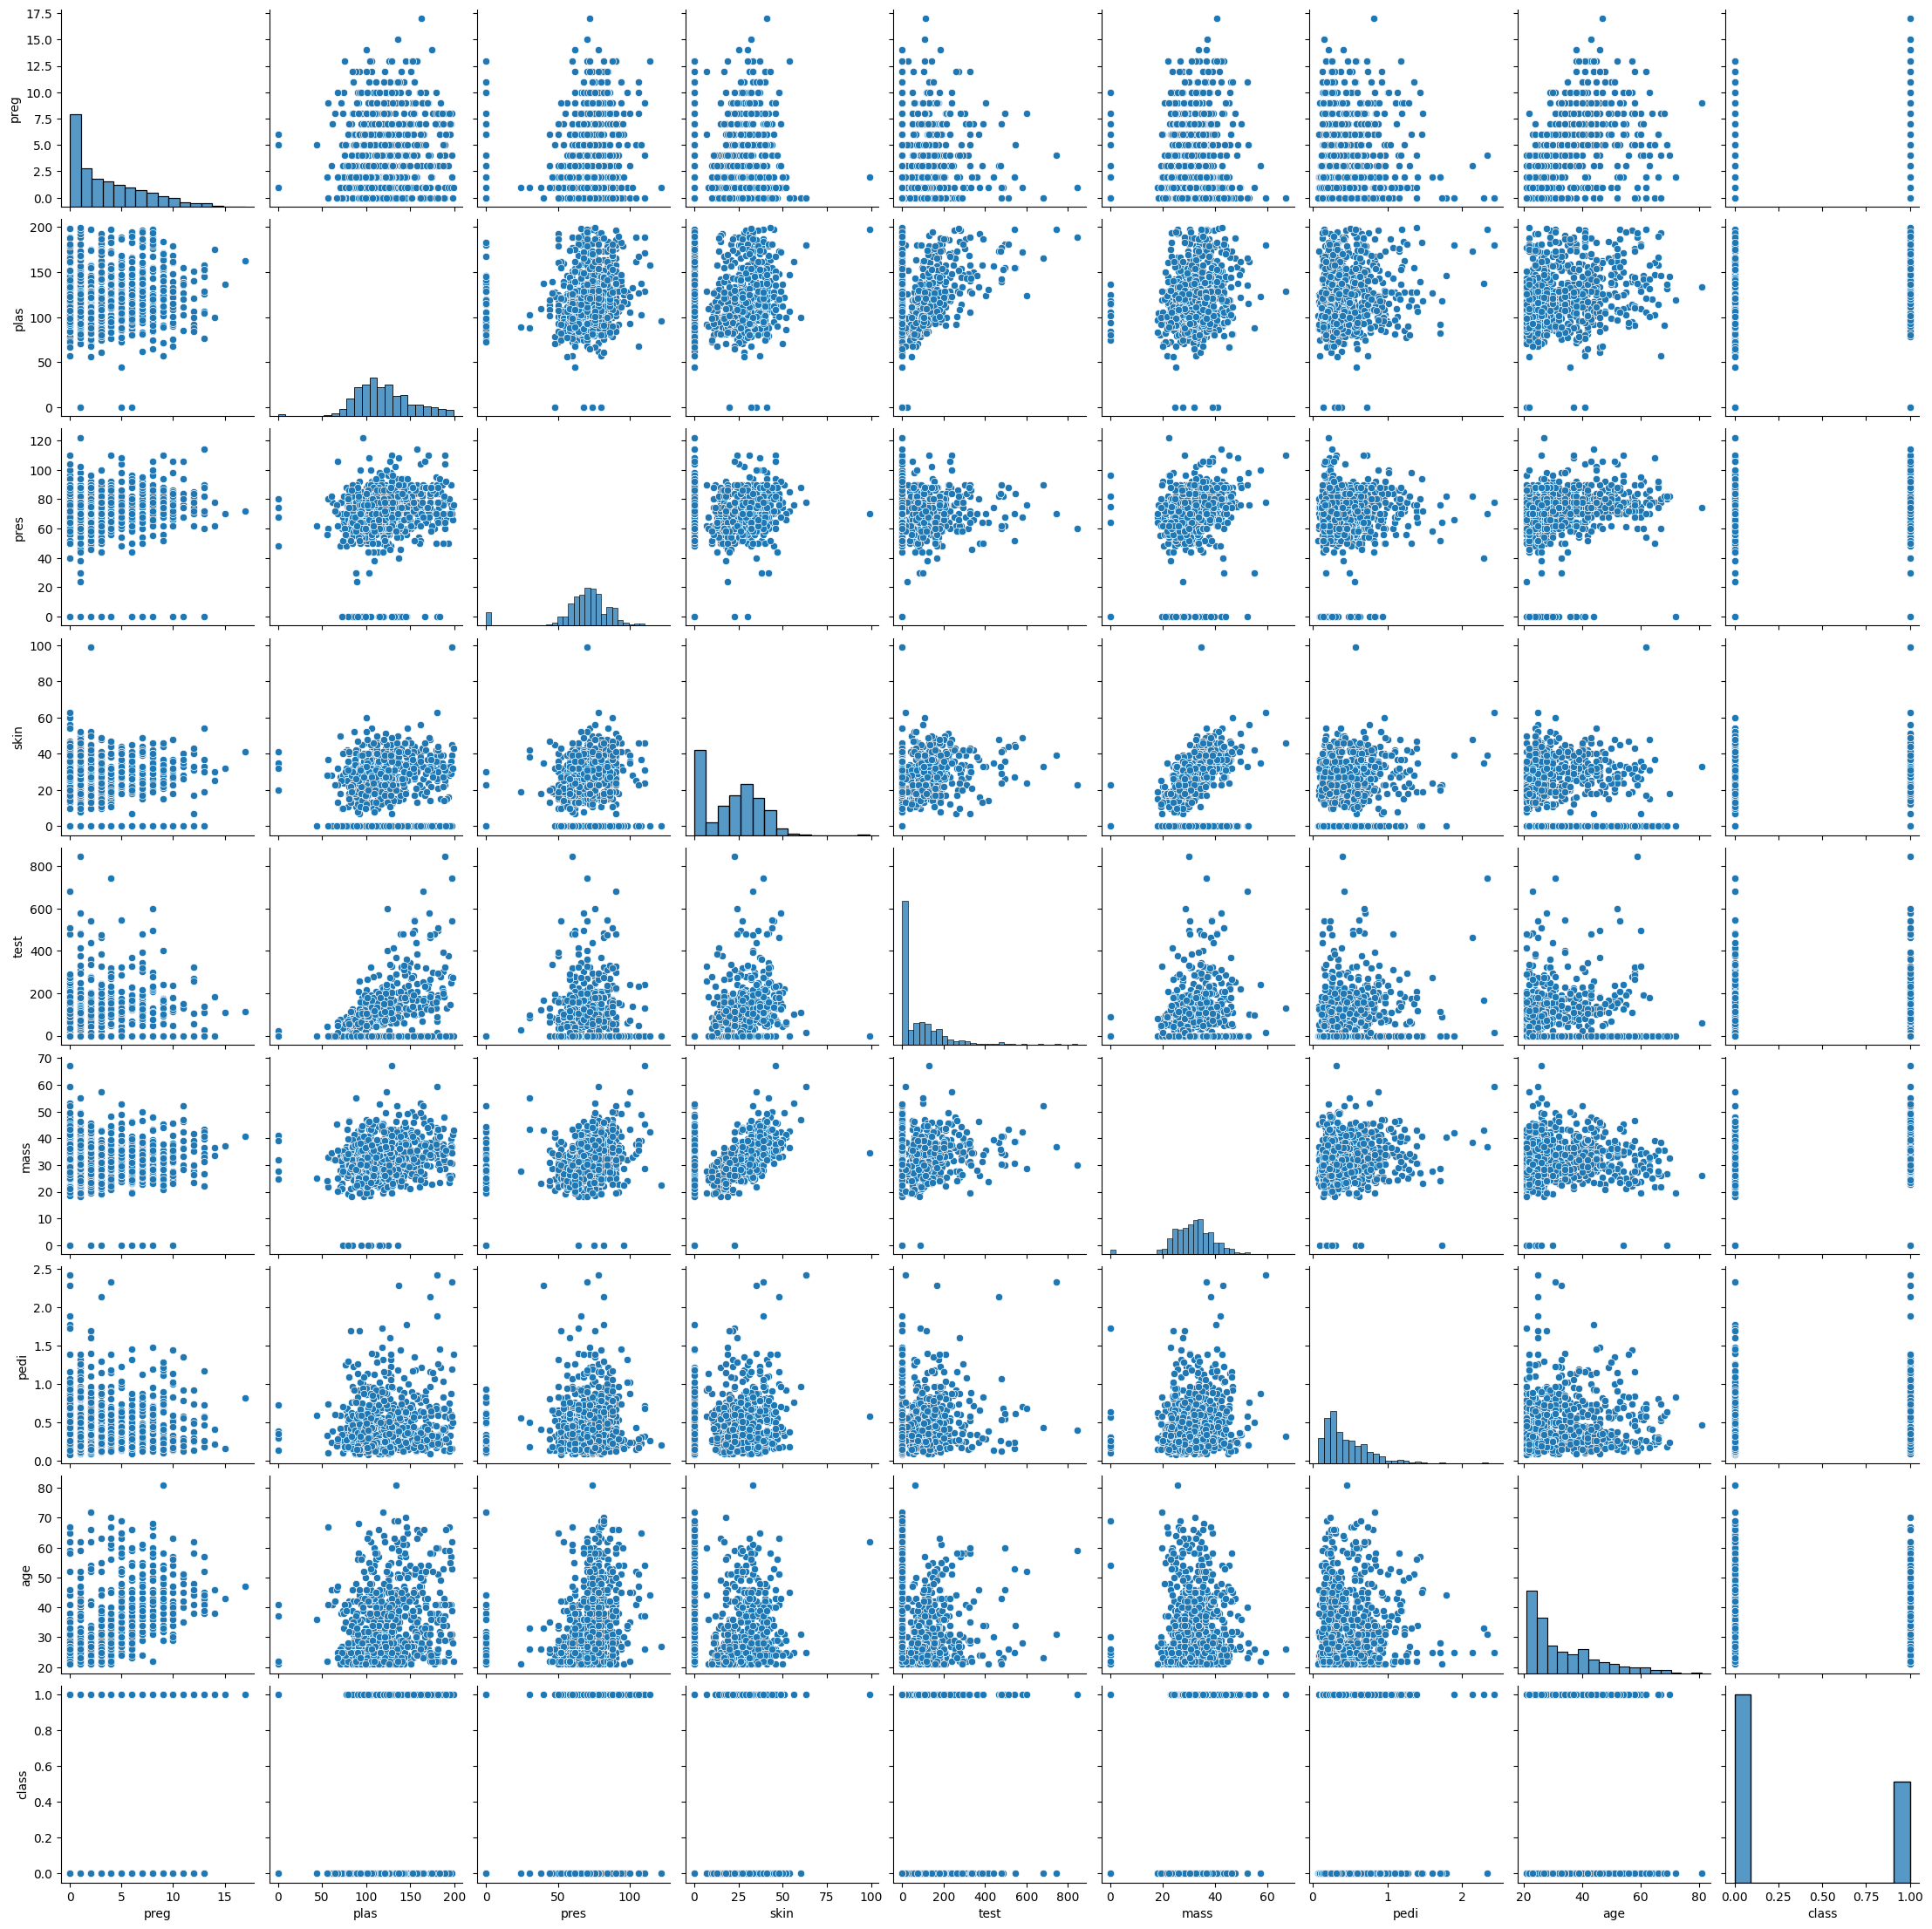

In [132]:
sns.pairplot(df_indios)

<Axes: >

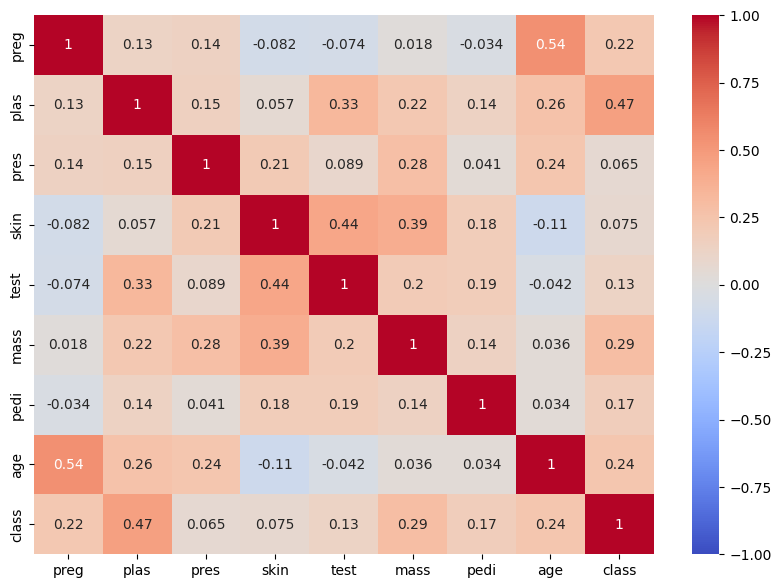

In [133]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_indios.corr(), annot=True, vmin=-1, cmap="coolwarm")

In [134]:
df_indios.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3. Bagging
Para este apartado tendrás que crear un ensemble utilizando la técnica de bagging ([BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)), mediante la cual combinarás 100 [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). Recuerda utilizar también [cross validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) con 10 kfolds.

**Para este apartado y siguientes, no hace falta que dividas en train/test**, por hacerlo más sencillo. Simplemente divide tus datos en features y target.

Establece una semilla

In [135]:
X = df_indios.drop(columns="class")
y = df_indios["class"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=55)

In [140]:
estimator = DecisionTreeClassifier(max_depth=3, random_state=42)

bag_clf = BaggingClassifier(
    estimator = estimator,
    n_estimators=100, 
    max_samples=100, 
    bootstrap=True, 
    random_state=42)

bag_clf.fit(X, y)
y_pred_bag = bag_clf.predict(X)
bagging_ac = accuracy_score(y, y_pred_bag)
print(bagging_ac)

0.78125


In [137]:
name='Logistic Regression'
# PARTIMOS EN 10 PAQUETES, EL NUMERO DE INTERACIONES CORRESPONDE CON EL NUMERO DE PAQUETES
kfold = KFold(n_splits=10, shuffle=True) #Parte los datos en 10 trozos para usar validación cruzada / cross validation
cv_results = cross_val_score(bag_clf, X, y, cv=kfold, scoring='accuracy')

msg =  (name, cv_results.mean(), cv_results.std())
print(cv_results)
print("____________________________________")
print(msg)

[0.74025974 0.74025974 0.67532468 0.81818182 0.76623377 0.76623377
 0.80519481 0.75324675 0.78947368 0.73684211]
____________________________________
('Logistic Regression', np.float64(0.7591250854408749), np.float64(0.03859743271383158))


### 4. Random Forest
En este caso entrena un [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) con 100 árboles y un `max_features` de 3. También con validación cruzada

In [138]:
rnd_clf = RandomForestClassifier(n_estimators=100,
                                 max_leaf_nodes=16,
                                 max_features=3,
                                 random_state=42)
rnd_clf.fit(X, y)

y_pred_rf = rnd_clf.predict(X)
# np.sum(y_test == y_pred_rf) / len(y_test) 
randomForest_ac = accuracy_score(y, y_pred_rf)
print(randomForest_ac)

0.8333333333333334


In [139]:
name='Logistic Regression'
# PARTIMOS EN 10 PAQUETES, EL NUMERO DE INTERACIONES CORRESPONDE CON EL NUMERO DE PAQUETES
kfold = KFold(n_splits=10, shuffle=True) #Parte los datos en 10 trozos para usar validación cruzada / cross validation
cv_results = cross_val_score(rnd_clf, X, y, cv=kfold, scoring='accuracy')

msg =  (name, cv_results.mean(), cv_results.std())
print(cv_results)
print("____________________________________")
print(msg)

[0.68831169 0.81818182 0.83116883 0.76623377 0.71428571 0.80519481
 0.75324675 0.76623377 0.68421053 0.77631579]
____________________________________
('Logistic Regression', np.float64(0.7603383458646616), np.float64(0.048840697596806114))


### 5. AdaBoost
Implementa un [AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) con 30 árboles.

In [141]:
estimator = DecisionTreeClassifier(max_depth=3, random_state=42)

ada_clf = AdaBoostClassifier(estimator = estimator,
                             n_estimators=30,
                             # Se puede elegir el valor que se quiera, varia de cero a infinito
                             learning_rate=0.5,
                             random_state=42)

ada_clf.fit(X, y)

y_pred_ada = ada_clf.predict(X)
adaBoost_ac = accuracy_score(y, y_pred_ada)
print(adaBoost_ac)

0.8255208333333334


### 6. GradientBoosting
Implementa un [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) con 100 estimadores

In [148]:
gbrt = GradientBoostingClassifier(max_depth=3,
                                 n_estimators=100,
                                 learning_rate=0.5,
                                 random_state=42)
gbrt.fit(X, y)

y_pred_gbrt = gbrt.predict(X)
gradientBoosting_ac = accuracy_score(y, y_pred_gbrt)
print(gradientBoosting_ac)

1.0


### 7. XGBoost
Para este apartado utiliza un [XGBoostClassifier](https://docs.getml.com/latest/api/getml.predictors.XGBoostClassifier.html) con 100 estimadores. XGBoost no forma parte de la suite de modelos de sklearn, por lo que tendrás que instalarlo con pip install

In [149]:
xgb_clas = xgboost.XGBClassifier(max_depth=3,
                                 n_estimators=100,
                                 learning_rate=0.5,
                                 random_state=42)

xgb_clas.fit(X, y)
y_pred_xgb = xgb_clas.predict(X)
xgBoost_ac = accuracy_score(y, y_pred_xgb)
print(xgBoost_ac)

0.99609375


### 8. Primeros resultados
Crea un dataframe con los resultados y sus algoritmos, ordenándolos de mayor a menor

In [150]:
dict = {
    "Bagging": bagging_ac,
    "RandomForest": randomForest_ac,
    "AdaBoost" : adaBoost_ac,
    "GradientBoosting": gradientBoosting_ac,
    "XGBoost" : xgBoost_ac
}

df_resultados = pd.DataFrame(list(dict.items()), columns=["Algoritmo", "Accuracy"])
df_resultados = df_resultados.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
df_resultados

,Algoritmo,Accuracy
0,GradientBoosting,1.000000
1,XGBoost,0.996094
2,RandomForest,0.833333
3,AdaBoost,0.825521
4,Bagging,0.781250


### 9. Hiperparametrización
Vuelve a entrenar los modelos de nuevo, pero esta vez dividiendo el conjunto de datos en train/test y utilizando un gridsearch para encontrar los mejores hiperparámetros.

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

### Bagging

In [152]:
estimator = DecisionTreeClassifier(max_depth=3, random_state=42)

bag_clf_02 = BaggingClassifier(
    estimator = estimator,
    n_estimators=100, 
    max_samples=100, 
    bootstrap=True, 
    random_state=42)

bag_clf_02.fit(X_train, y_train)
y_pred_bag_02 = bag_clf.predict(X_test)
bagging_ac_02 = accuracy_score(y_test, y_pred_bag_02)
print(bagging_ac_02)

0.7727272727272727


In [162]:
params = {"estimator__max_depth": range(2, 11)}

gs_dtf = GridSearchCV(bag_clf_02, param_grid=params, cv=5, scoring="accuracy")
gs_dtf.fit(X_train, y_train)

print(gs_dtf.best_estimator_)
bag_cv_ac = gs_dtf.best_score_
print(gs_dtf.best_score_)
print(gs_dtf.best_params_)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4,
                                                   random_state=42),
                  max_samples=100, n_estimators=100, random_state=42)
0.7769292283086766
{'estimator__max_depth': 4}


### RandomForest

In [154]:
rnd_clf_02 = RandomForestClassifier(n_estimators=100,
                                 max_leaf_nodes=16,
                                 max_features=3,
                                 random_state=42)
rnd_clf_02.fit(X_train, y_train)

y_pred_rf_02 = rnd_clf_02.predict(X_test)
# np.sum(y_test == y_pred_rf) / len(y_test) 
randomForest_ac_02 = accuracy_score(y_test, y_pred_rf_02)
print(randomForest_ac_02)

0.7597402597402597


In [163]:
params = {
    "max_depth": [2, 3, 4],
    "max_leaf_nodes": [4, 8, 16],
    "max_features": [3, 5, 7]
    }

gs_rf = GridSearchCV(rnd_clf_02, param_grid=params, cv=5, scoring="accuracy")
gs_rf.fit(X_train, y_train)

print(gs_rf.best_estimator_)
rf_cv_ac = gs_rf.best_score_
print(gs_rf.best_score_)
print(gs_rf.best_params_)

RandomForestClassifier(max_depth=4, max_features=3, max_leaf_nodes=16,
                       random_state=42)
0.7687724910035986
{'max_depth': 4, 'max_features': 3, 'max_leaf_nodes': 16}


### AdaBoost

In [170]:
estimator = DecisionTreeClassifier(max_depth=3, random_state=42)

ada_clf_02 = AdaBoostClassifier(estimator = estimator,
                                n_estimators=30,
                                # Se puede elegir el valor que se quiera, varia de cero a infinito
                                learning_rate=0.5,
                                random_state=42)

ada_clf_02.fit(X_train, y_train)

y_pred_ada_02 = ada_clf_02.predict(X_test)
adaBoost_ac_02 = accuracy_score(y_test, y_pred_ada_02)
print(adaBoost_ac_02)

0.7532467532467533


In [172]:
params = {
    "estimator__max_depth": [2, 3, 4],      
    "n_estimators": [30, 50, 100, 200],  
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0] 
}

gs_ada = GridSearchCV(ada_clf_02, param_grid=params, cv=5, scoring="accuracy")
gs_ada.fit(X_train, y_train)

print(gs_ada.best_estimator_)
ada_cv_ac = gs_ada.best_score_
print(gs_ada.best_score_)
print(gs_ada.best_params_)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=42),
                   learning_rate=0.05, n_estimators=200, random_state=42)
0.7850193256030921
{'estimator__max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200}


### GradientBoosting

In [173]:
gbrt = GradientBoostingClassifier(max_depth=3,
                                 n_estimators=100,
                                 learning_rate=0.5,
                                 random_state=42)
gbrt.fit(X_train, y_train)

y_pred_gbrt = gbrt.predict(X_test)
gradientBoosting_ac_02 = accuracy_score(y_test, y_pred_gbrt)
print(gradientBoosting_ac_02)

0.7272727272727273


In [174]:
params = {
    "n_estimators": [30, 50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "max_depth": [2, 3, 4]
}

gs_gb = GridSearchCV(gbrt, param_grid=params, cv=5, scoring="accuracy")
gs_gb.fit(X_train, y_train)
gb_cv_ac = gs_gb.best_score_
print(gs_gb.best_estimator_)
print(gs_gb.best_score_)
print(gs_gb.best_params_)

GradientBoostingClassifier(max_depth=4, n_estimators=30, random_state=42)
0.7817672930827668
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 30}


### XGBoost
Para este apartado utiliza un [XGBoostClassifier](https://docs.getml.com/latest/api/getml.predictors.XGBoostClassifier.html) con 100 estimadores. XGBoost no forma parte de la suite de modelos de sklearn, por lo que tendrás que instalarlo con pip install

In [177]:
xgb_clas = xgboost.XGBClassifier(max_depth=3,
                                 n_estimators=100,
                                 learning_rate=0.5,
                                 random_state=42)

xgb_clas.fit(X_train, y_train)
y_pred_xgb = xgb_clas.predict(X_test)
xgBoost_ac_02 = accuracy_score(y_test, y_pred_xgb)
print(xgBoost_ac_02)

0.6818181818181818


In [179]:
params = {
    "n_estimators": [30, 50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "max_depth": [2, 3, 4]
}

xgb_gb = GridSearchCV(xgb_clas, param_grid=params, cv=5, scoring="accuracy")
xgb_gb.fit(X_train, y_train)
xgb_cv_ac = xgb_gb.best_score_
print(xgb_gb.best_estimator_)
print(xgb_gb.best_score_)
print(xgb_gb.best_params_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
0.7834199653471945
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


### 10. Conclusiones finales

Escogemos el modelo que mejor generalice, es decir, el que tenga mejor métrica ante test (RF hiperparametrizado)

In [180]:
dict_02 = {
    "Bagging": bagging_ac_02,
    "RandomForest": randomForest_ac_02,
    "AdaBoost" : adaBoost_ac_02,
    "GradientBoosting": gradientBoosting_ac_02,
    "XGBoost" : xgBoost_ac_02
}

dict_02_cv = {
    "Bagging": bag_cv_ac,
    "RandomForest": rf_cv_ac,
    "AdaBoost" : ada_cv_ac,
    "GradientBoosting": gb_cv_ac,
    "XGBoost" : xgb_cv_ac
}

df_resultados_02 = pd.DataFrame(list(dict_02.items()), columns=["Algoritmo", "Accuracy"])

df_resultados_02["Accuracy_GCV"] = df_resultados_02["Algoritmo"].map(dict_02_cv)

df_resultados_02 = df_resultados_02.sort_values(by="Accuracy_GCV", ascending=False).reset_index(drop=True)

df_resultados_02

,Algoritmo,Accuracy,Accuracy_GCV
0,AdaBoost,0.753247,0.785019
1,XGBoost,0.681818,0.783420
2,GradientBoosting,0.727273,0.781767
3,Bagging,0.772727,0.776929
4,RandomForest,0.759740,0.768772


Aunque Bagging muestra la mayor Accuracy sobre el test, el RandomForest hiperparametrizado mediante GridSearchCV presenta un buen balance entre Accuracy simple y optimizada, lo que indica que es el modelo que mejor generaliza y el mas recomendable.